# Phase 2: Data Summarization and Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
df = pd.read_csv("/content/Raw_dataset.csv")
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


## 1. Data Analysis
In this section, the dataset is analyzed using summaries and visualizations to better understand its structure, distributions, missing values, and class label balance.

In [ ]:
# Dataset shape
print("Dataset shape:", df.shape)

Dataset shape: (2149, 35)


The dataset contains 2149 rows and 35 columns. This confirms that the dataset satisfies the project requirement of having more than 500 records and more than 10 attributes.

In [ ]:
# General dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

The dataset information shows the number of non-null values and data types for each attribute. Most attributes are numerical, while one attribute is categorical. This step helps understand the dataset structure before preprocessing.

In [ ]:
# Data types
df.dtypes

,0
PatientID,int64
Age,int64
Gender,int64
Ethnicity,int64
EducationLevel,int64
BMI,float64
Smoking,int64
AlcoholConsumption,float64
PhysicalActivity,float64
DietQuality,float64


This output displays the data type of each attribute. Identifying data types is important because numerical and categorical variables require different preprocessing techniques.

In [ ]:
# Missing values analysis
missing_values = df.isnull().sum()
missing_values

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


The missing values analysis shows that there are no missing values in the dataset. Therefore, no imputation or removal of incomplete records is required before further analysis.

In [ ]:
# Statistical summary for numerical attributes
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


The statistical summary provides descriptive measures such as mean, standard deviation, minimum, maximum, and quartiles for numerical attributes. These values help understand the spread, range, and variability of the data.

In [ ]:
# Five-number summary for numerical columns
five_number_summary = df.describe().loc[["min", "25%", "50%", "75%", "max"]]
five_number_summary

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
min,4751.0,60.0,0.0,0.0,0.0,15.008851,0.0,0.002003,0.003616,0.009385,...,0.000460,0.0,0.0,0.001288,0.0,0.0,0.0,0.0,0.0,0.0
25%,5288.0,67.0,0.0,0.0,1.0,21.611408,0.0,5.139810,2.570626,2.458455,...,2.566281,0.0,0.0,2.342836,0.0,0.0,0.0,0.0,0.0,0.0
50%,5825.0,75.0,1.0,0.0,1.0,27.823924,0.0,9.934412,4.766424,5.076087,...,5.094439,0.0,0.0,5.038973,0.0,0.0,0.0,0.0,0.0,0.0
75%,6362.0,83.0,1.0,1.0,2.0,33.869778,1.0,15.157931,7.427899,7.558625,...,7.546981,0.0,0.0,7.581490,0.0,0.0,0.0,0.0,1.0,1.0
max,6899.0,90.0,1.0,3.0,3.0,39.992767,1.0,19.989293,9.987429,9.998346,...,9.996467,1.0,1.0,9.999747,1.0,1.0,1.0,1.0,1.0,1.0


The five-number summary shows the minimum, first quartile, median, third quartile, and maximum values for numerical attributes. This helps identify the data spread and detect possible outliers before preprocessing.

In [ ]:
# Class label distribution
df["Forgetfulness"].value_counts()

,count
Forgetfulness,
0,1501
1,648


The class label distribution shows the number of instances in each Forgetfulness class. Class 0 has more instances than class 1, indicating that the target variable is slightly imbalanced.

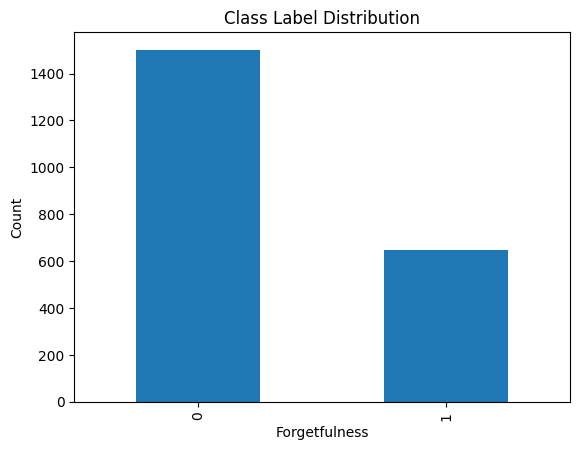

In [ ]:
# Plot class label distribution
df["Forgetfulness"].value_counts().plot(kind="bar")
plt.title("Class Label Distribution")
plt.xlabel("Forgetfulness")
plt.ylabel("Count")
plt.show()

This bar plot shows the distribution of the target class `Forgetfulness`. It helps determine whether the dataset is balanced or imbalanced across class labels.

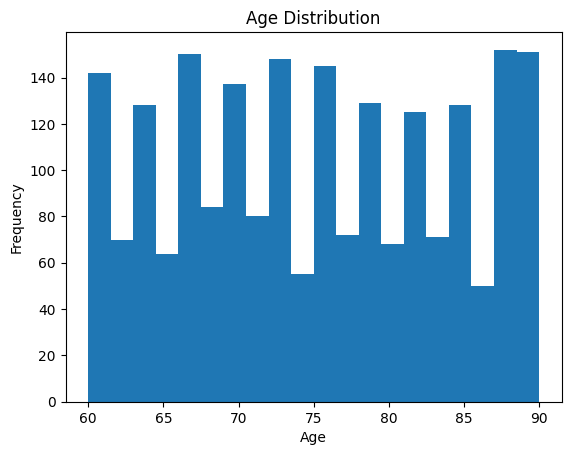

In [ ]:
# Histogram for Age
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

This histogram shows the distribution of the Age variable across the dataset. It helps understand how age values are spread and supports the decision to apply scaling during preprocessing.

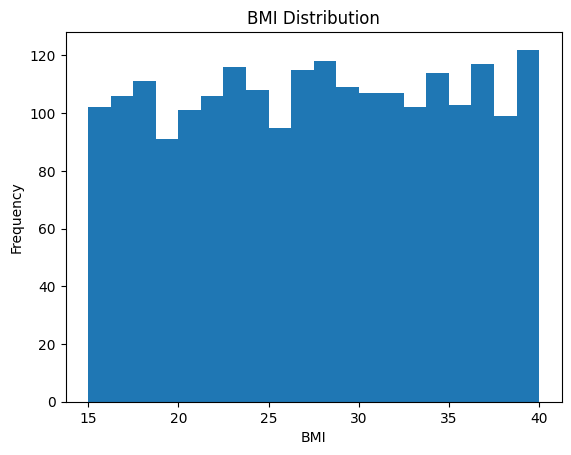

In [ ]:
# Histogram for BMI
plt.hist(df["BMI"], bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

This histogram illustrates the distribution of BMI values. Understanding the BMI distribution supports the decision to transform BMI into meaningful categories during preprocessing.

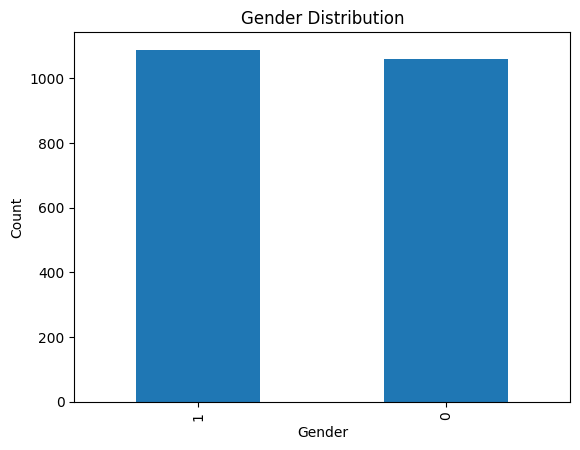

In [ ]:
# Bar plot for Gender
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

This bar plot shows the distribution of the Gender variable. Since Gender is a categorical attribute, it will be handled appropriately during preprocessing and feature selection.

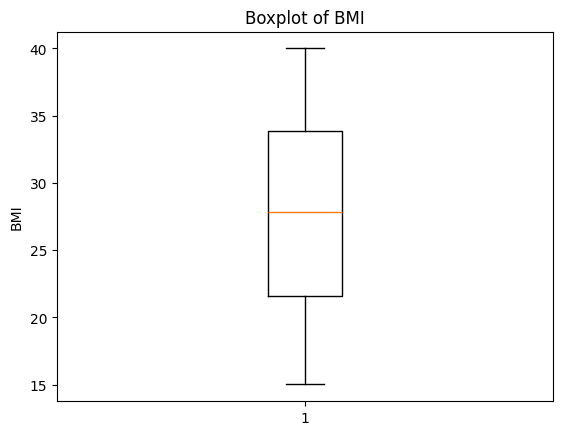

In [ ]:
# Boxplot for BMI
plt.boxplot(df["BMI"].dropna())
plt.title("Boxplot of BMI")
plt.ylabel("BMI")
plt.show()

This boxplot illustrates the distribution of BMI values, showing the median, interquartile range (IQR), and potential outliers. It helps identify the spread and variability of BMI, as well as detect any extreme values that may affect data analysis.

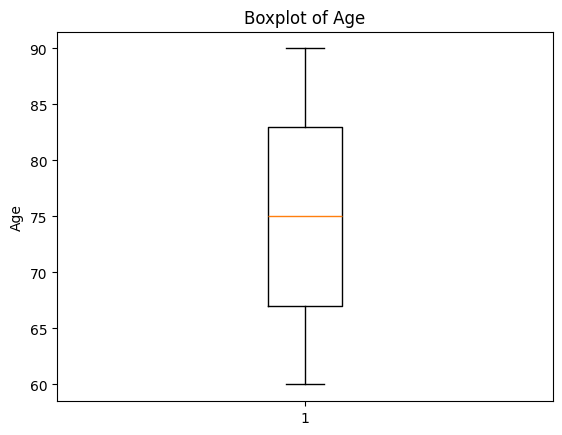

In [ ]:
# Boxplot for Age
plt.boxplot(df["Age"].dropna())
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

This boxplot shows the distribution of Age values, including the median, quartiles, and possible outliers. It provides insight into the variability and spread of age within the dataset and helps identify any unusual or extreme values.

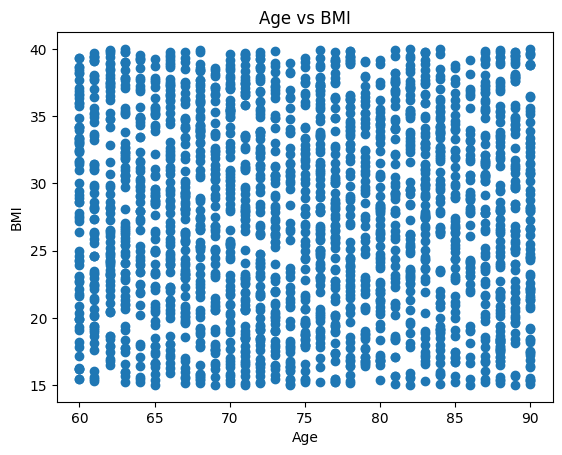

In [ ]:
# Scatter plot between Age and BMI
plt.scatter(df["Age"], df["BMI"])
plt.title("Age vs BMI")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()

This scatter plot shows the relationship between Age and BMI. No clear linear pattern is observed, which suggests that the two variables do not have a strong direct relationship.

In [ ]:
# Outlier detection using IQR for BMI
Q1 = df["BMI"].quantile(0.25)
Q3 = df["BMI"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_bmi = df[(df["BMI"] < lower_bound) | (df["BMI"] > upper_bound)]
print("Number of BMI outliers:", outliers_bmi.shape[0])
outliers_bmi[["BMI"]].head()

Number of BMI outliers: 0


,BMI


Outliers were detected using the Interquartile Range (IQR) method. The lower and upper bounds were calculated based on Q1 and Q3, and any values outside this range were considered outliers. This step helps identify extreme values that may negatively impact model performance, The results showed that there are no significant outliers in the BMI feature.

# **2. Data Preprocessing**
In this section, preprocessing techniques are applied to improve data quality and prepare the dataset for classification and clustering. According to the project requirements, at least three preprocessing techniques should be applied, excluding attribute removal and dataset splitting. The main preprocessing techniques used here are:

1. Discretization of BMI  
2. Feature Selection using Chi-square  
3. Standardization of numerical attributes  

In addition, the identifier column `PatientID` is removed as a cleaning step because it does not contribute to the prediction task.

In [ ]:
# Snapshot of the raw dataset before preprocessing
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


This snapshot presents a preview of the dataset before preprocessing. It helps in understanding the structure of the data, the types of features, and the initial values, which is important for identifying necessary preprocessing steps.

In [ ]:
# Discretization of BMI into medical categories
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

df[["BMI", "BMI_Category"]].head()

,BMI,BMI_Category
0,22.927749,Normal
1,26.827681,Overweight
2,17.795882,Underweight
3,33.800817,Obese
4,20.716974,Normal


The BMI variable was discretized into four medical categories: Underweight, Normal, Overweight, and Obese. This transformation converts a continuous variable into categorical groups, making the data easier to interpret and analyze. It also allows the model to capture patterns related to BMI categories rather than raw numerical values.

In [ ]:
# Count instances in each BMI category
df["BMI_Category"].value_counts()

,count
BMI_Category,
Obese,871
Normal,544
Overweight,437
Underweight,297


The distribution of BMI categories shows how instances are divided across different groups. The Obese category has the highest number of instances, while Underweight has the lowest, indicating an imbalance in BMI categories. This insight is important for understanding the dataset composition and its potential impact on model performance.

In [ ]:
# Remove identifier column
df = df.drop("PatientID", axis=1)
df.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge,BMI_Category
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,0,1.725883,0,0,0,1,0,0,XXXConfid,Normal
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,0,2.592424,0,0,0,0,1,0,XXXConfid,Overweight
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,0,7.119548,0,1,0,1,0,0,XXXConfid,Underweight
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,1,6.481226,0,0,0,0,0,0,XXXConfid,Obese
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,0,0.014691,0,0,1,1,0,0,XXXConfid,Normal


The PatientID column was removed as it serves only as a unique identifier and does not contribute any meaningful information for prediction. Keeping such features may negatively affect model performance.

In [ ]:
from sklearn.feature_selection import chi2

In [ ]:
TARGET = "Forgetfulness"

nominal_cols = [
    "Gender", "Ethnicity", "EducationLevel", "Smoking",
    "FamilyHistoryAlzheimers", "CardiovascularDisease", "Diabetes",
    "Depression", "HeadInjury", "Hypertension",
    "MemoryComplaints", "BehavioralProblems", "Confusion",
    "Disorientation", "PersonalityChanges", "DifficultyCompletingTasks"
]

# Convert categorical attributes to dummy variables
X_nominal = pd.get_dummies(df[nominal_cols].astype("category"))
y = df[TARGET]

# Apply Chi-square test
chi_scores, p_values = chi2(X_nominal, y)

chi_results = pd.DataFrame({
    "Feature": X_nominal.columns,
    "Chi2 Score": chi_scores,
    "p-value": p_values
}).sort_values(by="Chi2 Score", ascending=False)

chi_results.head(10)

,Feature,Chi2 Score,p-value
31,Disorientation_1,1.853966,0.173323
23,Hypertension_1,1.638542,0.200526
5,Ethnicity_3,1.307982,0.252760
4,Ethnicity_2,1.167246,0.279968
27,BehavioralProblems_1,0.989999,0.319743
0,Gender_0,0.886003,0.346563
1,Gender_1,0.864015,0.352617
13,FamilyHistoryAlzheimers_1,0.801924,0.370519
19,Depression_1,0.545705,0.460078
2,Ethnicity_0,0.503160,0.478115


Chi-square feature selection was applied to evaluate the relationship between categorical features and the target variable (Forgetfulness). The Chi-square score indicates the strength of association, while the p-value reflects statistical significance. Features with higher scores are considered more relevant for predicting the target variable.

In [ ]:
# Select top categorical features based on Chi-square
top_features = chi_results.head(10)["Feature"].tolist()
X_selected_nominal = X_nominal[top_features]

print("Top selected features:")
print(top_features)

X_selected_nominal.head()

Top selected features:
['Disorientation_1', 'Hypertension_1', 'Ethnicity_3', 'Ethnicity_2', 'BehavioralProblems_1', 'Gender_0', 'Gender_1', 'FamilyHistoryAlzheimers_1', 'Depression_1', 'Ethnicity_0']


,Disorientation_1,Hypertension_1,Ethnicity_3,Ethnicity_2,BehavioralProblems_1,Gender_0,Gender_1,FamilyHistoryAlzheimers_1,Depression_1,Ethnicity_0
0,False,False,False,False,False,True,False,False,True,True
1,False,False,False,False,False,True,False,False,False,True
2,True,False,True,False,False,True,False,True,False,False
3,False,False,False,False,True,False,True,False,False,True
4,False,False,False,False,False,True,False,False,False,True


The top categorical features were selected based on their Chi-square scores. This step reduces less relevant features and retains only the most informative ones, which helps improve model performance and reduces computational complexity,The results show that features such as Disorientation and Hypertension have higher Chi-square scores, indicating a stronger relationship with the target variable.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Select numerical columns only (excluding target)
numerical_cols = df.drop(columns=["Forgetfulness"]).select_dtypes(include=["int64", "float64"]).columns
numerical_cols = numerical_cols.drop("BMI")

X_numeric = df[numerical_cols]
y = df["Forgetfulness"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_cols)
X_scaled_df.head()

,Age,Gender,Ethnicity,EducationLevel,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Diagnosis
0,-0.212368,-1.012644,-0.700408,0.788833,-0.636784,0.565923,0.492525,-1.253593,1.119918,-0.580753,...,0.779037,0.497506,-0.512477,-0.431257,-1.104434,-0.508131,-0.433531,-0.421348,2.302619,-0.7397
1,1.567757,-1.012644,-0.700408,-1.422782,-0.636784,-0.954895,0.945093,-1.538442,0.056836,-0.580753,...,0.680297,0.704907,-0.512477,-0.431257,-0.810601,-0.508131,-0.433531,-0.421348,-0.434288,-0.7397
2,-0.212368,-1.012644,2.311955,-0.316974,-0.636784,1.653006,1.023896,-1.088855,1.487380,1.721901,...,-0.859222,0.281813,-0.512477,-0.431257,0.724491,-0.508131,2.306640,-0.421348,2.302619,-0.7397
3,-0.101111,0.987514,-0.700408,-0.316974,1.570391,0.376930,1.227995,0.839804,0.760833,-0.580753,...,-0.088723,1.343346,-0.512477,2.318805,0.508044,-0.508131,-0.433531,-0.421348,-0.434288,-0.7397
4,1.567757,-1.012644,-0.700408,-1.422782,-0.636784,1.461793,0.486696,-1.443293,-0.824566,-0.580753,...,-0.143712,0.333665,-0.512477,-0.431257,-1.684679,-0.508131,-0.433531,2.373334,2.302619,-0.7397


Standardization was applied to numerical features using StandardScaler, which transforms the data to have a mean of zero and a standard deviation of one. This ensures that all features are on a comparable scale, preventing features with larger values from dominating the model and improving model stability and performance.

In [ ]:
# Convert discretized BMI categories into dummy variables
bmi_dummies = pd.get_dummies(df["BMI_Category"], prefix="BMI_Category")
bmi_dummies.head()

,BMI_Category_Underweight,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese
0,False,True,False,False
1,False,False,True,False
2,True,False,False,False
3,False,False,False,True
4,False,True,False,False


The BMI_Category feature was transformed into dummy variables using one-hot encoding. This process converts categorical values into a binary format, allowing machine learning algorithms to process them without assuming any ordinal relationship between categories.

In [ ]:
# Construct the final preprocessed dataset
processed_df = pd.concat(
    [
        X_scaled_df.reset_index(drop=True),
        X_selected_nominal.reset_index(drop=True),
        bmi_dummies.reset_index(drop=True),
        y.reset_index(drop=True)
    ],
    axis=1
)

processed_df.head()

,Age,Gender,Ethnicity,EducationLevel,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,...,Gender_0,Gender_1,FamilyHistoryAlzheimers_1,Depression_1,Ethnicity_0,BMI_Category_Underweight,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese,Forgetfulness
0,-0.212368,-1.012644,-0.700408,0.788833,-0.636784,0.565923,0.492525,-1.253593,1.119918,-0.580753,...,True,False,False,True,True,False,True,False,False,0
1,1.567757,-1.012644,-0.700408,-1.422782,-0.636784,-0.954895,0.945093,-1.538442,0.056836,-0.580753,...,True,False,False,False,True,False,False,True,False,1
2,-0.212368,-1.012644,2.311955,-0.316974,-0.636784,1.653006,1.023896,-1.088855,1.487380,1.721901,...,True,False,True,False,False,True,False,False,False,0
3,-0.101111,0.987514,-0.700408,-0.316974,1.570391,0.376930,1.227995,0.839804,0.760833,-0.580753,...,False,True,False,False,True,False,False,False,True,0
4,1.567757,-1.012644,-0.700408,-1.422782,-0.636784,1.461793,0.486696,-1.443293,-0.824566,-0.580753,...,True,False,False,False,True,False,True,False,False,0


The final preprocessed dataset was constructed by combining standardized numerical features, selected categorical features obtained through Chi-square feature selection, and the one-hot encoded BMI categories. The target variable (Forgetfulness) was also included to complete the dataset for modeling.

In [ ]:
# Shape of the processed dataset
processed_df.shape

(2149, 46)

The processed dataset consists of 2149 samples and 46 features. The increase in the number of features is mainly due to one-hot encoding of categorical variables, which expands each category into separate binary features while preserving important information.

The final preprocessed dataset was constructed by combining:
- standardized numerical features,
- selected categorical features obtained through Chi-square,
- discretized BMI categories,
- and the target class.

This processed dataset is more suitable for classification and clustering than the raw dataset.

In [ ]:
# Snapshot of the preprocessed dataset
processed_df.head()

,Age,Gender,Ethnicity,EducationLevel,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,...,Gender_0,Gender_1,FamilyHistoryAlzheimers_1,Depression_1,Ethnicity_0,BMI_Category_Underweight,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese,Forgetfulness
0,-0.212368,-1.012644,-0.700408,0.788833,-0.636784,0.565923,0.492525,-1.253593,1.119918,-0.580753,...,True,False,False,True,True,False,True,False,False,0
1,1.567757,-1.012644,-0.700408,-1.422782,-0.636784,-0.954895,0.945093,-1.538442,0.056836,-0.580753,...,True,False,False,False,True,False,False,True,False,1
2,-0.212368,-1.012644,2.311955,-0.316974,-0.636784,1.653006,1.023896,-1.088855,1.487380,1.721901,...,True,False,True,False,False,True,False,False,False,0
3,-0.101111,0.987514,-0.700408,-0.316974,1.570391,0.376930,1.227995,0.839804,0.760833,-0.580753,...,False,True,False,False,True,False,False,False,True,0
4,1.567757,-1.012644,-0.700408,-1.422782,-0.636784,1.461793,0.486696,-1.443293,-0.824566,-0.580753,...,True,False,False,False,True,False,True,False,False,0


The snapshot above shows the final preprocessed dataset after applying all transformations.

In [ ]:
# Save the final processed dataset
processed_df.to_csv("Preprocessed_dataset.csv", index=False)
print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


### Preprocessing Summary and Improvement

Three main preprocessing techniques were applied in this phase:

1. **Discretization** on BMI to convert it into meaningful health-related categories.  
2. **Feature Selection** using Chi-square to retain the most relevant categorical attributes.  
3. **Standardization** on numerical features to remove scale differences.  

These preprocessing steps improved the dataset in several ways. Discretization increased interpretability, feature selection reduced irrelevant information, and standardization prepared numerical variables for fair comparison. As a result, the dataset became cleaner, more structured, and better optimized for machine learning tasks such as classification and clustering. Additionally, preprocessing helped reduce noise and redundancy, improving model performance and generalization.